# India Data Jobs Pulse: Skills & Hiring Demand Analysis (2026)

Analysing 12,000+ Naukri job postings to answer three questions:
- Which skills are Indian data roles demanding heading into 2026?
- Which cities are the biggest hiring hubs?
- Do skill requirements differ by city?

**Dataset:** Naukri Data Science Jobs India (Kaggle)   
**Tools:** Python, Pandas, Looker Studio/Data Studio


In [20]:
%pip install -q pandas numpy matplotlib seaborn plotly gspread gspread-dataframe kaggle

from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/india-data-jobs-analysis"
project_root = Path(PROJECT_DIR)
raw_data_dir = project_root / "data_raw"
clean_data_dir = project_root / "data_processed"
dashboard_export_dir = project_root / "exports"

for folder in [raw_data_dir, clean_data_dir, dashboard_export_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Raw data folder: {raw_data_dir}")
print(f"Processed data folder: {clean_data_dir}")
print(f"Exports folder: {dashboard_export_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/india-data-jobs-analysis
Raw data folder: /content/drive/MyDrive/india-data-jobs-analysis/data_raw
Processed data folder: /content/drive/MyDrive/india-data-jobs-analysis/data_processed
Exports folder: /content/drive/MyDrive/india-data-jobs-analysis/exports


In [21]:
import shutil
shutil.copy(
    Path.home() / ".kaggle/kaggle.json",
    project_root / "kaggle.json"
)
print("kaggle.json saved to Drive permanently")

kaggle.json saved to Drive permanently


## Section 0 : Environment Setup
Installing libraries and mounting Google Drive. Folder structure:
`data_raw/` → raw download
`data_processed/` → cleaned data
`exports/` → charts and CSVs

In [22]:
import os
import shutil
import subprocess
from pathlib import Path

import pandas as pd
from google.colab import files

try:
    india_jobs_slug = "anandhuh/data-science-jobs-in-india"
    kaggle_home = Path.home() / ".kaggle"
    kaggle_home.mkdir(parents=True, exist_ok=True)
    active_kaggle_json = kaggle_home / "kaggle.json"
    saved_kaggle_json = project_root / "kaggle.json"

    if not active_kaggle_json.exists():
        if saved_kaggle_json.exists():
            shutil.copy(saved_kaggle_json, active_kaggle_json)
            print(f"Kaggle credentials source: Copied from {saved_kaggle_json}")
        else:
            print("Kaggle credentials needed: Upload kaggle.json in the file picker for this Section 1 cell.")
            uploaded = files.upload()
            if "kaggle.json" not in uploaded:
                raise FileNotFoundError("kaggle.json was not uploaded. Rerun this cell and upload the Kaggle API file.")

            notebook_kaggle_json = Path("/content/kaggle.json")
            if not notebook_kaggle_json.exists():
                notebook_kaggle_json = Path("kaggle.json")
            shutil.move(str(notebook_kaggle_json), active_kaggle_json)
            print(f"Kaggle credentials upload: Saved to {active_kaggle_json}")

    os.chmod(active_kaggle_json, 0o600)

    kaggle_download_args = [
        "kaggle",
        "datasets",
        "download",
        "-d",
        india_jobs_slug,
        "-p",
        str(raw_data_dir),
        "--unzip",
    ]
    kaggle_run = subprocess.run(kaggle_download_args, check=True, capture_output=True, text=True)
    print(f"Kaggle download status: {kaggle_run.stdout.strip() or 'Completed with no stdout'}")
    print(f"Kaggle download notes: {kaggle_run.stderr.strip() or 'No stderr messages'}")

    raw_csv_candidates = sorted(raw_data_dir.glob("*.csv"), key=lambda path: path.stat().st_size, reverse=True)
    if not raw_csv_candidates:
        raise FileNotFoundError(f"No CSV files were found in {raw_data_dir} after the Kaggle download.")

    raw_jobs_file = raw_csv_candidates[0]
    df = pd.read_csv(raw_jobs_file)
    raw_row_count = len(df)

    print(f"Loaded CSV file: {raw_jobs_file}")
    print(f"Raw dataframe shape: {df.shape}")
    print(f"Raw dataframe column names: {list(df.columns)}")
    print("Raw dataframe first 5 rows:")
    display(df.head())
    print("Raw dataframe null counts per column:")
    display(df.isna().sum().sort_values(ascending=False).to_frame("null_count"))

except Exception as error:
    print(f"Kaggle download/load error: {type(error).__name__}: {error}")
    print("Kaggle download/load help: Check that Section 0 ran, your kaggle.json file is valid, and the Kaggle API is enabled in your Kaggle account settings.")
    raise


Kaggle download status: Dataset URL: https://www.kaggle.com/datasets/anandhuh/data-science-jobs-in-india
License(s): DbCL-1.0
Kaggle download notes: 0%|          | 0.00/480k [00:00<?, ?B/s]
100%|██████████| 480k/480k [00:00<00:00, 30.7MB/s]
Loaded CSV file: /content/drive/MyDrive/india-data-jobs-analysis/data_raw/naukri_data_science_jobs_india.csv
Raw dataframe shape: (12000, 5)
Raw dataframe column names: ['Job_Role', 'Company', 'Location', 'Job Experience', 'Skills/Description']
Raw dataframe first 5 rows:


,Job_Role,Company,Location,Job Experience,Skills/Description
0,Senior Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",3-6,"python, MLT, statistical modeling, machine lea..."
1,Senior Data Scientist,Walmart,Bangalore/Bengaluru,5-9,"Data Science, Machine learning, Python, Azure,..."
2,Applied Data Scientist / ML Senior Engineer (P...,SAP India Pvt.Ltd,Bangalore/Bengaluru,5-10,"Python, IT Skills, Testing, Cloud, Product Man..."
3,Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",1-4,"python, machine learning, Data Science, data a..."
4,Data Scientist,Walmart,Bangalore/Bengaluru,4-8,"IT Skills, Python, Data Science, Machine Learn..."


Raw dataframe null counts per column:


,null_count
Job_Role,0
Company,0
Location,0
Job Experience,0
Skills/Description,0


## Section 1 : Raw Data Overview
Dataset has 12,000 rows across 5 columns: Job Role, Company, Location, Job Experience, Skills/Description.

No null values detected. Skills are stored as text descriptions, will be extracted using regex in Section 4.

In [23]:
import re

def tidy_column_label(label):
    tidy_label = str(label).strip().lower()
    tidy_label = re.sub(r"[^a-z0-9]+", "_", tidy_label)
    tidy_label = re.sub(r"_+", "_", tidy_label)
    return tidy_label.strip("_")


def keep_column_labels_unique(labels):
    label_tracker = {}
    final_labels = []
    for label in labels:
        if label not in label_tracker:
            label_tracker[label] = 0
            final_labels.append(label)
        else:
            label_tracker[label] += 1
            final_labels.append(f"{label}_{label_tracker[label]}")
    return final_labels


def choose_column_from_keywords(columns, include_terms, prefer_terms=None, exclude_terms=None):
    prefer_terms = prefer_terms or []
    exclude_terms = exclude_terms or []
    possible_matches = []

    for column in columns:
        column_text = str(column).lower()
        if any(term in column_text for term in exclude_terms):
            continue

        matched_terms = [term for term in include_terms if term in column_text]
        if matched_terms:
            match_score = len(matched_terms) * 10
            match_score += sum(5 for term in prefer_terms if term in column_text)
            match_score -= len(column_text) / 100
            possible_matches.append((match_score, column))

    if not possible_matches:
        return None

    possible_matches = sorted(possible_matches, key=lambda item: item[0], reverse=True)
    return possible_matches[0][1]


rows_entering_cleanup = len(df)
raw_column_labels = list(df.columns)

df = df.copy()
df.columns = keep_column_labels_unique([tidy_column_label(column) for column in df.columns])

rows_after_column_cleanup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after_duplicate_check = len(df)

role_title_col = choose_column_from_keywords(
    df.columns,
    include_terms=["job_title", "title", "role", "designation", "position", "job"],
    prefer_terms=["job_title", "title", "role"],
    exclude_terms=["description", "desc", "skill", "skills", "company", "location", "city", "salary", "experience"],
)

job_location_col = choose_column_from_keywords(
    df.columns,
    include_terms=["location", "city", "place", "state", "region"],
    prefer_terms=["location", "city"],
    exclude_terms=["company", "salary", "title", "role", "description", "desc", "skill", "skills"],
)

if role_title_col is None:
    raise ValueError("Could not detect a job title column. Inspect the printed columns from Section 1 and manually set role_title_col in Section 2.")

if job_location_col is None:
    raise ValueError("Could not detect a location/city column. Inspect the printed columns from Section 1 and manually set job_location_col in Section 2.")

print(f"Rows before cleaning: {rows_entering_cleanup}")
print(f"Rows before duplicate removal: {rows_after_column_cleanup}")
print(f"Rows after exact duplicate removal: {rows_after_duplicate_check}")
print(f"Rows removed as exact duplicates: {rows_after_column_cleanup - rows_after_duplicate_check}")
print(f"Original column names: {raw_column_labels}")
print(f"Standardized column names: {list(df.columns)}")
print(f"Detected job title column: {role_title_col}")
print(f"Detected location/city column: {job_location_col}")
print("Column override tip: If either detected column is wrong, replace the role_title_col or job_location_col value in this Section 2 cell with the correct standardized column name, then rerun Sections 2 onward.")


Rows before cleaning: 12000
Rows before duplicate removal: 12000
Rows after exact duplicate removal: 12000
Rows removed as exact duplicates: 0
Original column names: ['Job_Role', 'Company', 'Location', 'Job Experience', 'Skills/Description']
Standardized column names: ['job_role', 'company', 'location', 'job_experience', 'skills_description']
Detected job title column: job_role
Detected location/city column: location
Column override tip: If either detected column is wrong, replace the role_title_col or job_location_col value in this Section 2 cell with the correct standardized column name, then rerun Sections 2 onward.


## Section 2 : Data Cleaning
Standardised column names to snake_case and removed exact duplicates.

Zero duplicates found: dataset is already unique at the row level.

In [24]:
import re

DATA_ROLE_KEYWORDS = [
    "data analyst",
    "business analyst",
    "data scientist",
    "data engineer",
    "analytics",
    "bi analyst",
    "machine learning",
    "sql analyst",
    "ml engineer",
    "mis analyst",
    "reporting analyst",
    "decision scientist",
    "analytics consultant",
]

data_role_search_regex = "|".join(re.escape(keyword) for keyword in DATA_ROLE_KEYWORDS)
df_jobs = df[
    df[role_title_col]
    .fillna("")
    .astype(str)
    .str.contains(data_role_search_regex, case=False, regex=True)
].copy()

original_share_pct = (len(df_jobs) / raw_row_count * 100) if raw_row_count else 0

print(f"Data role keyword list: {DATA_ROLE_KEYWORDS}")
print(f"Rows remaining in df_jobs: {len(df_jobs)}")
print(f"Percent of original dataset kept: {original_share_pct:.1f}%")
print("Sample filtered job titles and locations:")
display(df_jobs[[role_title_col, job_location_col]].head())


Data role keyword list: ['data analyst', 'business analyst', 'data scientist', 'data engineer', 'analytics', 'bi analyst', 'machine learning', 'sql analyst', 'ml engineer', 'mis analyst', 'reporting analyst', 'decision scientist', 'analytics consultant']
Rows remaining in df_jobs: 6952
Percent of original dataset kept: 57.9%
Sample filtered job titles and locations:


,job_role,location
0,Senior Data Scientist,"Bangalore/Bengaluru, Mumbai (All Areas)"
1,Senior Data Scientist,Bangalore/Bengaluru
2,Applied Data Scientist / ML Senior Engineer (P...,Bangalore/Bengaluru
3,Data Scientist,"Bangalore/Bengaluru, Mumbai (All Areas)"
4,Data Scientist,Bangalore/Bengaluru


## Section 3 : Filtering to Data Roles
Filtered 12,000 rows down to 6,952 data role postings (57% of dataset).

Roles included:  
Data Analyst,  
Data Scientist,  
Data Engineer,  
Business Analyst,  
ML Engineer and 8 others.

Data Engineer is the most posted role suggesting higher hiring volume for pipeline/infrastructure work over pure analysis.

In [25]:
import re

SKILLS = [
    "SQL",
    "Python",
    "Excel",
    "Tableau",
    "Power BI",
    "Looker",
    "BigQuery",
    "Spark",
    "dbt",
    "Airflow",
    "Git",
    "Pandas",
    "NumPy",
    "Scikit-learn",
    "TensorFlow",
    "AWS",
    "Azure",
    "GCP",
    "Statistics",
    "NLP",
    "Power Query",
    "Looker Studio",
    "MySQL",
    "PostgreSQL",
    "Alteryx",
]


def make_skill_regex(skill_name):
    escaped_name = re.escape(skill_name)
    escaped_name = escaped_name.replace(r"\ ", r"[\s\-]+")
    escaped_name = escaped_name.replace(r"\-", r"[\s\-]+")
    return re.compile(rf"(?<![A-Za-z0-9+#.]){escaped_name}(?![A-Za-z0-9+#.])", re.IGNORECASE)


searchable_text_cols = df_jobs.select_dtypes(include=["object", "string"]).columns.tolist()
if not searchable_text_cols:
    searchable_text_cols = list(df_jobs.columns)

posting_text_blob = df_jobs[searchable_text_cols].fillna("").astype(str).agg(" ".join, axis=1)
skill_regex_map = {skill: make_skill_regex(skill) for skill in SKILLS}

df_jobs["skills_found"] = posting_text_blob.apply(
    lambda posting_text: [skill for skill, skill_regex in skill_regex_map.items() if skill_regex.search(posting_text)]
)

skill_hit_counts = {
    skill: int(df_jobs["skills_found"].apply(lambda found_skills: skill in found_skills).sum())
    for skill in SKILLS
}

top_skills = pd.DataFrame(
    {
        "skill": list(skill_hit_counts.keys()),
        "job_count": list(skill_hit_counts.values()),
    }
)
top_skills["pct_of_jobs"] = (
    top_skills["job_count"].div(len(df_jobs)).mul(100).round(1) if len(df_jobs) else 0.0
)
top_skills = top_skills.sort_values(["job_count", "skill"], ascending=[False, True]).reset_index(drop=True)

print(f"Skill search text columns: {searchable_text_cols}")
print("Top 15 skills by job count:")
display(top_skills.head(15))


Skill search text columns: ['job_role', 'company', 'location', 'job_experience', 'skills_description']
Top 15 skills by job count:


,skill,job_count,pct_of_jobs
0,Python,2312,33.3
1,SQL,1609,23.1
2,AWS,818,11.8
3,Spark,783,11.3
4,Azure,713,10.3
5,Tableau,522,7.5
6,Excel,374,5.4
7,MySQL,241,3.5
8,GCP,223,3.2
9,Git,151,2.2


## Section 4 : Skill Extraction
Searched all text columns for 25 curated skills using regex to avoid false matches.

Python leads at 33.3%  
SQL at 23.1%  
AWS at 11.8%  

Notable: Cloud skills (AWS + Azure + GCP combined = ~25%) now rival SQL is signalling that cloud fluency
is becoming baseline for Indian data roles, not just a differentiator.

In [26]:
print("Columns in df_jobs: " + str(list(df_jobs.columns)))


Columns in df_jobs: ['job_role', 'company', 'location', 'job_experience', 'skills_description', 'skills_found']


In [27]:
cleaned_city_names = (
    df_jobs[job_location_col]
    .fillna("Unknown")
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)
cleaned_city_names = cleaned_city_names.mask(cleaned_city_names.eq("") | cleaned_city_names.str.lower().isin(["nan", "none"]), "Unknown")
df_jobs["city"] = cleaned_city_names

city_demand = (
    df_jobs["city"]
    .value_counts()
    .rename_axis("city")
    .reset_index(name="job_count")
)

df_jobs["city"] = df_jobs["city"].replace({
    "Bangalore/Bengaluru": "Bengaluru",
    "Hyderabad/Secunderabad": "Hyderabad",
    "Gurgaon/Gurugram": "Gurugram"
})

print("Top 15 cities by data-role demand:")
display(city_demand.head(15))


Top 15 cities by data-role demand:


,city,job_count
0,Bangalore/Bengaluru,1853
1,Pune,921
2,Hyderabad/Secunderabad,833
3,Mumbai,604
4,Gurgaon/Gurugram,551
5,Chennai,451
6,Noida,277
7,Bengaluru,206
8,Kolkata,167
9,Remote,107


## Section 5 : City Demand
Bangalore dominates with 1,853 postings (26.7%)  
Pune at 13%.  
Noida and Chennai together account for ~8% of demand.

In [28]:
city_skill_pivot = df_jobs[df_jobs["city"].isin(
    ["Bengaluru", "Pune", "Mumbai", "Hyderabad", "Gurugram"]
)].explode("skills_found").groupby(
    ["city", "skills_found"]
).size().unstack(fill_value=0)

display(city_skill_pivot)

skills_found,AWS,Airflow,Alteryx,Azure,BigQuery,Excel,GCP,Git,Looker,MySQL,...,Pandas,PostgreSQL,Python,SQL,Scikit-learn,Spark,Statistics,Tableau,TensorFlow,dbt
city,,,,,,,,,,,,,,,,,,,,,
Bengaluru,214,39,10,167,9,99,58,47,3,76,...,15,25,692,477,4,220,38,162,31,1
Gurugram,60,11,3,40,5,50,13,3,0,22,...,3,3,232,145,1,57,32,60,9,0
Hyderabad,140,12,3,161,17,34,41,28,1,22,...,5,11,328,259,0,150,14,69,5,1
Mumbai,63,3,3,43,3,42,19,7,0,23,...,2,2,138,120,2,49,18,58,6,1
Pune,133,14,4,92,7,20,30,43,1,32,...,8,10,263,160,5,96,4,45,8,2


In [29]:
cleaned_role_titles = df_jobs[role_title_col].fillna("Unknown").astype(str).str.strip()
cleaned_role_titles = cleaned_role_titles.mask(cleaned_role_titles.eq("") | cleaned_role_titles.str.lower().isin(["nan", "none"]), "Unknown")

role_demand = (
    cleaned_role_titles
    .value_counts()
    .rename_axis("role_title")
    .reset_index(name="job_count")
)

print("Top 20 role titles by posting count:")
display(role_demand.head(20))


Top 20 role titles by posting count:


,role_title,job_count
0,Data Engineer,580
1,Data Scientist,505
2,Data Analyst,353
3,Senior Technical Lead (Data Engineer),276
4,Senior Data Engineer,197
5,Business Analyst,197
6,Senior Data Scientist,97
7,Azure Data Engineer,80
8,Data Engineer: Data Integration,75
9,Big Data Engineer,71


## Section 6 : Role Demand
Data Engineer (580) leads over Data Scientist (505) and Data Analyst (353).

The gap between Engineer and Analyst postings suggests the Indian market currently values
data infrastructure builders more than insight generators relevant context for career positioning.

In [30]:
data_role_total = len(df_jobs)

lead_skill = top_skills.iloc[0] if not top_skills.empty else {"skill": "No skill found", "job_count": 0, "pct_of_jobs": 0.0}
lead_city = city_demand.iloc[0] if not city_demand.empty else {"city": "No city found", "job_count": 0}
lead_role = role_demand.iloc[0] if not role_demand.empty else {"role_title": "No role found", "job_count": 0}

lead_city_share = (lead_city["job_count"] / data_role_total * 100) if data_role_total else 0

def skill_share(skill_name):
    pct_values = top_skills.loc[top_skills["skill"].eq(skill_name), "pct_of_jobs"]
    return float(pct_values.iloc[0]) if not pct_values.empty else 0.0


sql_pct = skill_share("SQL")
python_pct = skill_share("Python")

top_ten_skill_rows = top_skills.head(10)
quiet_skill = (
    top_ten_skill_rows.sort_values(["job_count", "skill"], ascending=[True, True]).iloc[0]
    if not top_ten_skill_rows.empty
    else {"skill": "No skill found", "job_count": 0}
)

print(f"Top skill: {lead_skill['skill']} appears in {int(lead_skill['job_count'])} jobs ({float(lead_skill['pct_of_jobs']):.1f}% of data role postings)")
print(f"Top city: {lead_city['city']} has {int(lead_city['job_count'])} data role job postings ({lead_city_share:.1f}% of total)")
print(f"Most common role: {lead_role['role_title']} with {int(lead_role['job_count'])} postings")
print(f"SQL vs Python gap: SQL appears in {sql_pct:.1f}% of jobs, Python in {python_pct:.1f}%")
print(f"Underdog skill: the skill with lowest count among top-10 is {quiet_skill['skill']} at {int(quiet_skill['job_count'])} jobs")


Top skill: Python appears in 2312 jobs (33.3% of data role postings)
Top city: Bangalore/Bengaluru has 1853 data role job postings (26.7% of total)
Most common role: Data Engineer with 580 postings
SQL vs Python gap: SQL appears in 23.1% of jobs, Python in 33.3%
Underdog skill: the skill with lowest count among top-10 is Git at 151 jobs


## Section 7 : Key Findings
5 data driven findings extracted from 6,952 filtered postings.
These numbers form the core narrative of the Looker Studio dashboard.

## Section 8 : Visualisations
Two charts exported as PNG to `exports/` for use in GitHub README and dashboard.

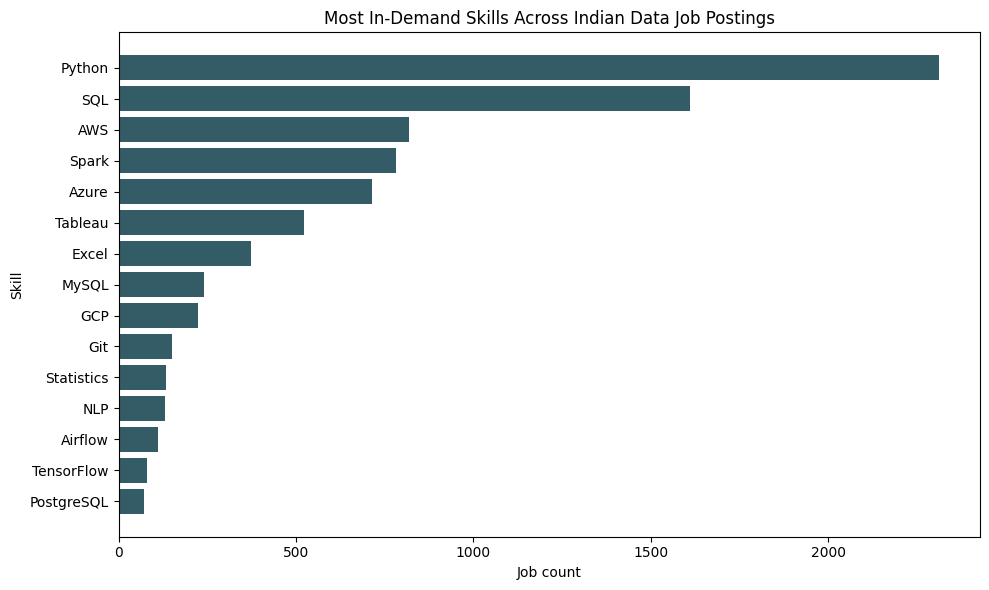

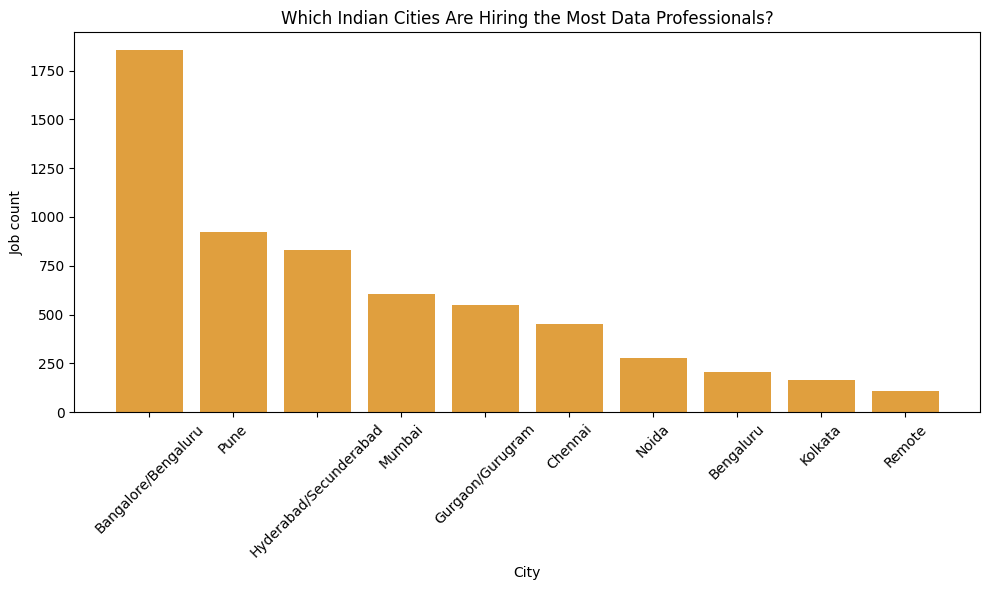

Saved top skills chart: /content/drive/MyDrive/india-data-jobs-analysis/exports/top_skills.png
Saved city demand chart: /content/drive/MyDrive/india-data-jobs-analysis/exports/city_demand.png


In [31]:
import matplotlib.pyplot as plt

plt.style.use("default")

skills_chart_path = dashboard_export_dir / "top_skills.png"
city_chart_path = dashboard_export_dir / "city_demand.png"

skills_for_chart = top_skills.head(15).sort_values("job_count", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(skills_for_chart["skill"], skills_for_chart["job_count"], color="#335C67")
ax.set_title("Most In-Demand Skills Across Indian Data Job Postings")
ax.set_xlabel("Job count")
ax.set_ylabel("Skill")
ax.grid(False)
fig.tight_layout()
fig.savefig(skills_chart_path, dpi=150, bbox_inches="tight")
plt.show()

cities_for_chart = city_demand.head(10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(cities_for_chart["city"], cities_for_chart["job_count"], color="#E09F3E")
ax.set_title("Which Indian Cities Are Hiring the Most Data Professionals?")
ax.set_xlabel("City")
ax.set_ylabel("Job count")
ax.tick_params(axis="x", labelrotation=45)
ax.grid(False)
fig.tight_layout()
fig.savefig(city_chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved top skills chart: {skills_chart_path}")
print(f"Saved city demand chart: {city_chart_path}")


In [32]:
summary = pd.DataFrame(
    [
        {"metric": "total_jobs", "value": int(len(df_jobs))},
        {"metric": "top_skill", "value": str(top_skills.iloc[0]["skill"]) if not top_skills.empty else "No skill found"},
        {"metric": "top_city", "value": str(city_demand.iloc[0]["city"]) if not city_demand.empty else "No city found"},
        {"metric": "unique_roles", "value": int(role_demand["role_title"].nunique()) if not role_demand.empty else 0},
    ]
)

print("Summary table for dashboard scorecards:")
display(summary)


Summary table for dashboard scorecards:


,metric,value
0,total_jobs,6952
1,top_skill,Python
2,top_city,Bangalore/Bengaluru
3,unique_roles,3094


In [33]:
import re

def format_skills_for_export(skill_value):
    if isinstance(skill_value, (list, tuple, set)):
        return ", ".join(str(skill) for skill in skill_value)
    if pd.isna(skill_value):
        return ""
    return str(skill_value)


LOOKER_COLUMN_NAMES = {
    "job_role": "Job Role",
    "company": "Company",
    "location": "Location",
    "job_experience": "Job Experience",
    "skills_description": "Skills Description",
    "skills_found": "Skills Found",
    "city": "City",
    "skill": "Skill",
    "job_count": "Job Count",
    "pct_of_jobs": "Percent of Jobs",
    "role_title": "Role Title",
    "metric": "Metric",
    "value": "Value",
}

LOOKER_WORD_FIXES = {
    "sql": "SQL",
    "bi": "BI",
    "ml": "ML",
    "aws": "AWS",
    "azure": "Azure",
    "gcp": "GCP",
    "nlp": "NLP",
    "dbt": "dbt",
}


def make_looker_column_name(column_name):
    clean_key = re.sub(r"[^a-z0-9]+", "_", str(column_name).strip().lower()).strip("_")
    if clean_key in LOOKER_COLUMN_NAMES:
        return LOOKER_COLUMN_NAMES[clean_key]

    words = clean_key.split("_")
    return " ".join(LOOKER_WORD_FIXES.get(word, word.title()) for word in words if word)


def make_looker_ready_table(dataframe):
    export_df = dataframe.copy()
    if "skills_found" in export_df.columns:
        export_df["skills_found"] = export_df["skills_found"].apply(format_skills_for_export)

    export_df = export_df.rename(
        columns={column: make_looker_column_name(column) for column in export_df.columns}
    )
    return export_df


df_jobs_export = make_looker_ready_table(df_jobs)
top_skills_export = make_looker_ready_table(top_skills)
city_demand_export = make_looker_ready_table(city_demand)
role_demand_export = make_looker_ready_table(role_demand)
summary_export = make_looker_ready_table(summary)

if "Metric" in summary_export.columns:
    summary_export["Metric"] = summary_export["Metric"].replace(
        {
            "total_jobs": "Total Jobs",
            "top_skill": "Top Skill",
            "top_city": "Top City",
            "unique_roles": "Unique Roles",
        }
    )

print(f"Looker cleaned jobs columns: {list(df_jobs_export.columns)}")
print(f"Looker top skills columns: {list(top_skills_export.columns)}")
print(f"Looker city demand columns: {list(city_demand_export.columns)}")
print(f"Looker role demand columns: {list(role_demand_export.columns)}")
print(f"Looker summary columns: {list(summary_export.columns)}")
print("Looker summary preview:")
display(summary_export)


Looker cleaned jobs columns: ['Job Role', 'Company', 'Location', 'Job Experience', 'Skills Description', 'Skills Found', 'City']
Looker top skills columns: ['Skill', 'Job Count', 'Percent of Jobs']
Looker city demand columns: ['City', 'Job Count']
Looker role demand columns: ['Role Title', 'Job Count']
Looker summary columns: ['Metric', 'Value']
Looker summary preview:


,Metric,Value
0,Total Jobs,6952
1,Top Skill,Python
2,Top City,Bangalore/Bengaluru
3,Unique Roles,3094


In [34]:
from google.colab import auth
auth.authenticate_user()

try:
    import gspread
    import google.auth
    from google.colab import auth
    from gspread_dataframe import set_with_dataframe

    auth.authenticate_user()
    google_credentials, _ = google.auth.default()
    sheets_client = gspread.authorize(google_credentials)

    pulse_workbook = sheets_client.create("India Data Jobs — Skills & Demand Analysis")

    dashboard_tables = {
        "summary": summary_export,
        "top_skills": top_skills_export,
        "city_demand": city_demand_export,
        "role_demand": role_demand_export,
    }

    for tab_index, (tab_name, table_df) in enumerate(dashboard_tables.items()):
        if tab_index == 0:
            worksheet = pulse_workbook.sheet1
            worksheet.update_title(tab_name)
        else:
            worksheet = pulse_workbook.add_worksheet(
                title=tab_name,
                rows=max(len(table_df) + 5, 100),
                cols=max(len(table_df.columns) + 2, 20),
            )

        worksheet.clear()
        set_with_dataframe(worksheet, table_df)
        print(f"Google Sheets export sheet: Wrote {tab_name} with {len(table_df)} rows")

    print(f"Google Sheets URL: {pulse_workbook.url}")

except Exception as error:
    print(f"Google Sheets export error: {type(error).__name__}: {error}")
    print("Google Sheets export help: Rerun this section, complete the Google auth flow, and confirm your account can create Google Sheets files.")


Google Sheets export sheet: Wrote summary with 4 rows
Google Sheets export sheet: Wrote top_skills with 25 rows
Google Sheets export sheet: Wrote city_demand with 167 rows
Google Sheets export sheet: Wrote role_demand with 3094 rows
Google Sheets URL: https://docs.google.com/spreadsheets/d/1oE4Kt0T_LzHLUsnckgdyU66vxvuEts9UU3DwHxe3DmI


In [35]:
cleaned_jobs_path = clean_data_dir / "cleaned_jobs.csv"
skills_table_path = dashboard_export_dir / "top_skills.csv"
city_table_path = dashboard_export_dir / "city_demand.csv"
role_table_path = dashboard_export_dir / "role_demand.csv"
summary_table_path = dashboard_export_dir / "summary.csv"

df_jobs_export.to_csv(cleaned_jobs_path, index=False)
top_skills_export.to_csv(skills_table_path, index=False)
city_demand_export.to_csv(city_table_path, index=False)
role_demand_export.to_csv(role_table_path, index=False)
summary_export.to_csv(summary_table_path, index=False)

print(f"Saved cleaned jobs CSV: {cleaned_jobs_path}")
print(f"Saved top skills CSV: {skills_table_path}")
print(f"Saved city demand CSV: {city_table_path}")
print(f"Saved role demand CSV: {role_table_path}")
print(f"Saved summary CSV: {summary_table_path}")


Saved cleaned jobs CSV: /content/drive/MyDrive/india-data-jobs-analysis/data_processed/cleaned_jobs.csv
Saved top skills CSV: /content/drive/MyDrive/india-data-jobs-analysis/exports/top_skills.csv
Saved city demand CSV: /content/drive/MyDrive/india-data-jobs-analysis/exports/city_demand.csv
Saved role demand CSV: /content/drive/MyDrive/india-data-jobs-analysis/exports/role_demand.csv
Saved summary CSV: /content/drive/MyDrive/india-data-jobs-analysis/exports/summary.csv


## Conclusion

Based on 6,952 Naukri data role postings analysed:

1. **Learn Python first, SQL second** : Python appears in 33% of postings vs SQL's 23%, reversing the traditional analyst stack priority
2. **Target Bengaluru or Pune** together they account for ~40% of all data role demand in India
3. **Add one cloud skill** AWS, Azure, or GCP now appear in 1 in 4 postings, making cloud literacy effectively non-optional

*Dashboard built in Looker Studio — link in README*